In [1]:
#Cell1
!pip install -q timm peft
import torch, torchvision, timm, peft
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")
print("timm    :", timm.__version__)
print("peft    :", peft.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

**| 2 | Config — set your DATA_ROOT here |**

In [2]:
#cell 3
import os, torch

DATA_ROOT = "/kaggle/input/datasets/vijayadurgaadithya/mimic-part/mimic_part_jpg"

# Verify it exists
assert os.path.exists(DATA_ROOT), f"Path not found: {DATA_ROOT}"
for split in ["train", "test"]:
    for cls in ["CHF", "Normal", "pneumonia"]:
        p = os.path.join(DATA_ROOT, split, cls)
        n = len(os.listdir(p)) if os.path.exists(p) else 0
        print(f"  {split}/{cls}: {n} images")

print("\nGaze folder contents:")
gaze_dir = os.path.join(DATA_ROOT, "gaze")
for f in os.listdir(gaze_dir):
    print(f"  {f}")

# ── Training config ────────────────────────────────────────────
CFG = {
    "num_classes":    3,
    "integration":    "two_way",
    "num_layers":     2,
    "num_heads":      8,
    "lora_rank":      8,
    "max_fixations":  50,
    "dropout":        0.1,
    "epochs":         50,
    "batch_size":     32,
    "lr":             2e-4,
    "weight_decay":   0.01,
    "warmup_epochs":  3,
    "img_size":       224,
    "num_workers":    2,
    "amp":            True,
    "grad_clip":      1.0,
    "patience":       10,
    "output_dir":     "/kaggle/working/checkpoints",

    #Adding ModelSaver Flags
    "saveCheckPoint": True,
    "KeepLastCheckpoint": True,
    "KeepBestCheckpoint": True,
    "saveCheckpointInterval": 5,
    "CheckpointsList": [1,15,25],
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABEL_NAMES = ["CHF", "Normal", "pneumonia"]
os.makedirs(CFG["output_dir"], exist_ok=True)
print(f"\nDevice: {DEVICE}")
print("Config ready.")


  train/CHF: 331 images
  train/Normal: 316 images
  train/pneumonia: 329 images
  test/CHF: 32 images
  test/Normal: 44 images
  test/pneumonia: 31 images

Gaze folder contents:
  fixations
  fixation_heatmaps
  heatmap.py
  fixations.csv
  eye_gaze.csv

Device: cuda
Config ready.


**| 3 | Inspect fixations.csv columns |
**

In [3]:
#Cell 5
import pandas as pd

csv_path = os.path.join(DATA_ROOT, "gaze", "fixations.csv")
df_raw = pd.read_csv(csv_path)

print("Shape     :", df_raw.shape)
print("Columns   :", list(df_raw.columns))
print("\nFirst 3 rows:")
print(df_raw.head(3).to_string())
print("\nPer-column stats:")
print(df_raw.describe(include="all").to_string())


Shape     : (48959, 37)
Columns   : ['SESSION_ID', 'MEDIA_ID', 'DICOM_ID', 'CNT', 'Time (in secs)', 'TIMETICK(f=10000000)', 'FPOGX', 'FPOGY', 'FPOGS', 'FPOGD', 'FPOGID', 'FPOGV', 'BPOGX', 'BPOGY', 'BPOGV', 'LPCX', 'LPCY', 'LPD', 'LPS', 'LPV', 'RPCX', 'RPCY', 'RPD', 'RPS', 'RPV', 'BKID', 'BKDUR', 'BKPMIN', 'LPMM', 'LPMMV', 'RPMM', 'RPMMV', 'SACCADE_MAG', 'SACCADE_DIR', 'VID_FRAME', 'X_ORIGINAL', 'Y_ORIGINAL']

First 3 rows:
   SESSION_ID  MEDIA_ID                                      DICOM_ID  CNT  Time (in secs)  TIMETICK(f=10000000)    FPOGX    FPOGY    FPOGS    FPOGD  FPOGID  FPOGV    BPOGX    BPOGY  BPOGV     LPCX     LPCY       LPD      LPS  LPV     RPCX     RPCY       RPD      RPS  RPV  BKID  BKDUR  BKPMIN     LPMM  LPMMV     RPMM  RPMMV  SACCADE_MAG  SACCADE_DIR  VID_FRAME  X_ORIGINAL  Y_ORIGINAL
0           1         0  1a3f39ce-ebe90275-9a66145a-af03360e-ee3b163b   45         0.72363          6.962164e+11  0.45224  0.33879  0.01794  0.70569       2      1  0.46134  0.26619     

**| 4 | Dataset & DataLoader |**

In [4]:
import os, numpy as np, pandas as pd, torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from glob import glob

LABEL_MAP = {"CHF": 0, "Normal": 1, "pneumonia": 2}

def get_transforms(mode, img_size=224):
    if mode == "train":
        return transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(5),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])


def load_fixations_csv(csv_path):
    df = pd.read_csv(csv_path)
    print(f"[CSV] Raw shape: {df.shape}")

    if "FPOGV" in df.columns:
        before = len(df)
        df = df[df["FPOGV"] == 1].copy()
        print(f"[CSV] Kept {len(df)}/{before} valid rows (FPOGV==1)")

    index = {}
    for dicom_id, grp in df.groupby("DICOM_ID"):
        x = grp["FPOGX"].values.astype(np.float32)
        y = grp["FPOGY"].values.astype(np.float32)
        t = grp["Time (in secs)"].values.astype(np.float32)
        d = grp["FPOGD"].values.astype(np.float32)

        t_norm = (t - t.min()) / (t.max() - t.min() + 1e-6)
        d_norm = np.clip(d / 2.0, 0.0, 1.0)
        x = np.clip(x, 0.0, 1.0)
        y = np.clip(y, 0.0, 1.0)

        fix = np.stack([x, y, t_norm, d_norm], axis=1)  # (N, 4)
        index[str(dicom_id).strip()] = fix

    print(f"[CSV] Built index for {len(index)} unique images")
    sample_key = next(iter(index))
    sample_fix = index[sample_key]
    print(f"[CSV] Sample shape={sample_fix.shape}  "
          f"x=[{sample_fix[:,0].min():.2f},{sample_fix[:,0].max():.2f}]  "
          f"y=[{sample_fix[:,1].min():.2f},{sample_fix[:,1].max():.2f}]")
    return index


class MimicGazeDataset(Dataset):
    def __init__(self, root, mode="train", img_size=224, max_fixations=50, csv_index=None):
        assert mode in ("train","test")
        self.root, self.mode = root, mode
        self.img_size = img_size
        self.max_fixations = max_fixations
        self.transform = get_transforms(mode, img_size)
        self.csv_index = csv_index or {}

        self.samples = []
        for label_name, label_idx in LABEL_MAP.items():
            for p in sorted(glob(os.path.join(root, mode, label_name, "*.jpg"))):
                self.samples.append((p, label_idx))

        if not self.samples:
            raise RuntimeError(f"No images found in {root}/{mode}/")

        matched = sum(1 for p,_ in self.samples
                      if os.path.splitext(os.path.basename(p))[0] in self.csv_index)
        print(f"[{mode}] {len(self.samples)} images | {matched} with real gaze | "
              f"{len(self.samples)-matched} synthetic fallback")

    def _get_fixations(self, img_path):
        key = os.path.splitext(os.path.basename(img_path))[0]
        if key not in self.csv_index:
            return np.array([[0.5, 0.5, 0.0, 0.2]], dtype=np.float32)
        fix = self.csv_index[key]
        return fix[:self.max_fixations]

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = self.transform(Image.open(img_path).convert("RGB"))
        fix = self._get_fixations(img_path)
        N   = len(fix)
        return {
            "image":    img,
            "gaze":     torch.from_numpy(fix),
            "gaze_len": torch.tensor(N, dtype=torch.long),
            "label":    torch.tensor(label, dtype=torch.long),
            "path":     img_path,
        }


def collate_fn(batch):
    images    = torch.stack([b["image"]    for b in batch])
    labels    = torch.stack([b["label"]    for b in batch])
    gaze_lens = torch.stack([b["gaze_len"] for b in batch])
    max_len   = gaze_lens.max().item()
    B         = len(batch)
    gaze_pad  = torch.zeros(B, max_len, 4)
    gaze_mask = torch.ones(B, max_len, dtype=torch.bool)

    for i, b in enumerate(batch):
        n = b["gaze_len"].item()
        gaze_pad[i, :n]  = b["gaze"]
        gaze_mask[i, :n] = False

    return {"image": images, "gaze": gaze_pad, "gaze_mask": gaze_mask,
            "gaze_len": gaze_lens, "label": labels,
            "path": [b["path"] for b in batch]}


# ── Build dataloaders ─────────────────────────────────────────────────────────
csv_index = load_fixations_csv(os.path.join(DATA_ROOT, "gaze", "fixations.csv"))

train_ds = MimicGazeDataset(DATA_ROOT, "train", CFG["img_size"], CFG["max_fixations"], csv_index)
test_ds  = MimicGazeDataset(DATA_ROOT, "test",  CFG["img_size"], CFG["max_fixations"], csv_index)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], collate_fn=collate_fn, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], collate_fn=collate_fn, pin_memory=True)

print(f"\nTrain batches: {len(train_loader)} | Test batches: {len(test_loader)}")

[CSV] Raw shape: (48959, 37)
[CSV] Kept 48959/48959 valid rows (FPOGV==1)
[CSV] Built index for 1142 unique images
[CSV] Sample shape=(19, 4)  x=[0.30,0.68]  y=[0.16,0.72]
[train] 976 images | 976 with real gaze | 0 synthetic fallback
[test] 107 images | 107 with real gaze | 0 synthetic fallback

Train batches: 31 | Test batches: 4


Diagnostic cell for cheking the pretrained weights of mgca

In [5]:
import torch
ckpt = torch.load("/kaggle/input/datasets/vijayadurgaadithya/mgca-weights/vit_base.ckpt", map_location="cpu")
state_dict = ckpt.get("state_dict", ckpt)
keys = list(state_dict.keys())
print(f"Total keys: {len(keys)}")
print("\nFirst 30 keys:")
for k in keys[:30]:
    print(f"  {k}  ->  shape {state_dict[k].shape if hasattr(state_dict[k], 'shape') else 'N/A'}")
print("\nLast 10 keys:")
for k in keys[-10:]:
    print(f"  {k}")

Total keys: 368

First 30 keys:
  img_encoder_q.model.cls_token  ->  shape torch.Size([1, 1, 768])
  img_encoder_q.model.pos_embed  ->  shape torch.Size([1, 197, 768])
  img_encoder_q.model.patch_embed.proj.weight  ->  shape torch.Size([768, 3, 16, 16])
  img_encoder_q.model.patch_embed.proj.bias  ->  shape torch.Size([768])
  img_encoder_q.model.blocks.0.norm1.weight  ->  shape torch.Size([768])
  img_encoder_q.model.blocks.0.norm1.bias  ->  shape torch.Size([768])
  img_encoder_q.model.blocks.0.attn.qkv.weight  ->  shape torch.Size([2304, 768])
  img_encoder_q.model.blocks.0.attn.qkv.bias  ->  shape torch.Size([2304])
  img_encoder_q.model.blocks.0.attn.proj.weight  ->  shape torch.Size([768, 768])
  img_encoder_q.model.blocks.0.attn.proj.bias  ->  shape torch.Size([768])
  img_encoder_q.model.blocks.0.norm2.weight  ->  shape torch.Size([768])
  img_encoder_q.model.blocks.0.norm2.bias  ->  shape torch.Size([768])
  img_encoder_q.model.blocks.0.mlp.fc1.weight  ->  shape torch.Size([30

**| 5 | Gaze Tokenizer |**

In [6]:
import math, torch, torch.nn as nn


class SinusoidalPosEnc(nn.Module):
    """Sinusoidal positional encoding for scalar time values in [0,1]."""
    def __init__(self, dim, max_len=5000):
        super().__init__()
        pe  = torch.zeros(max_len, dim)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, dim, 2, dtype=torch.float) * (-math.log(10000.0) / dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe)

    def forward(self, t_norm):
        """t_norm: (B, N) in [0,1] -> (B, N, dim)"""
        idx = (t_norm * (self.pe.shape[0] - 1)).long().clamp(0, self.pe.shape[0]-1)
        return self.pe[idx]


class GazeTokenizer(nn.Module):
    """
    Fixation (x, y, start_time, duration) -> token embedding (dim).

    Token = PosEnc(start_time) + Linear(duration) + Linear(x,y)
    """
    def __init__(self, dim=768, max_len=5000):
        super().__init__()
        self.spatial_proj  = nn.Linear(2, dim)
        self.duration_proj = nn.Linear(1, dim)
        self.pos_enc       = SinusoidalPosEnc(dim, max_len)
        self.norm          = nn.LayerNorm(dim)

    def forward(self, gaze, gaze_mask=None):
        """gaze: (B,N,4)  gaze_mask: (B,N) True=pad"""
        xy       = gaze[..., :2]      # (B,N,2)
        start    = gaze[..., 2]       # (B,N)
        duration = gaze[..., 3:4]     # (B,N,1)

        tokens = self.pos_enc(start) + self.duration_proj(duration) + self.spatial_proj(xy)
        tokens = self.norm(tokens)

        if gaze_mask is not None:
            tokens = tokens.masked_fill(gaze_mask.unsqueeze(-1), 0.0)
        return tokens   # (B,N,dim)

print("GazeTokenizer defined.")


GazeTokenizer defined.


**| 6 | Gaze Integration (Cross-Attention + Two-Way) |**

In [7]:
class CrossAttentionBlock(nn.Module):
    """Image tokens attend to gaze tokens (image=query, gaze=key/value)."""
    def __init__(self, dim, num_heads=8, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, dim*4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim*4, dim), nn.Dropout(dropout))

    def forward(self, img, gaze, key_padding_mask=None):
        out, _ = self.attn(img, gaze, gaze, key_padding_mask=key_padding_mask)
        img = self.norm1(img + out)
        return self.norm2(img + self.ffn(img))


class TwoWayAttentionBlock(nn.Module):
    """Bidirectional cross-attention (SAM mask-decoder style)."""
    def __init__(self, dim, num_heads=8, dropout=0.1):
        super().__init__()
        self.img2gaze  = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm1     = nn.LayerNorm(dim)
        self.gaze2img  = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2     = nn.LayerNorm(dim)
        self.self_attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm3     = nn.LayerNorm(dim)
        self.ffn       = nn.Sequential(
            nn.Linear(dim, dim*4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim*4, dim), nn.Dropout(dropout))
        self.norm4     = nn.LayerNorm(dim)

    def forward(self, img, gaze, gaze_mask=None):
        out, _ = self.img2gaze(img, gaze, gaze, key_padding_mask=gaze_mask)
        img    = self.norm1(img + out)
        out, _ = self.gaze2img(gaze, img, img)
        gaze   = self.norm2(gaze + out)
        out, _ = self.self_attn(img, img, img)
        img    = self.norm3(img + out)
        return self.norm4(img + self.ffn(img)), gaze


class ImageToGazeCrossAttention(nn.Module):
    def __init__(self, dim, num_layers=2, num_heads=8, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([CrossAttentionBlock(dim, num_heads, dropout) for _ in range(num_layers)])
    def forward(self, img, gaze, gaze_mask=None):
        for l in self.layers: img = l(img, gaze, gaze_mask)
        return img


class TwoWayAttention(nn.Module):
    def __init__(self, dim, num_layers=2, num_heads=8, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([TwoWayAttentionBlock(dim, num_heads, dropout) for _ in range(num_layers)])
    def forward(self, img, gaze, gaze_mask=None):
        for l in self.layers: img, gaze = l(img, gaze, gaze_mask)
        return img

print("Gaze integration modules defined.")


Gaze integration modules defined.


**| 7 | Full FixationFormer model |**

In [8]:
import timm
from peft import LoraConfig, get_peft_model


class ViTImageEncoder(nn.Module):
    def __init__(self, model_name="vit_base_patch16_224", pretrained=False,
                 lora_rank=8, use_lora=True, mgca_path=None):
        super().__init__()
        self.vit = timm.create_model(model_name, pretrained=False, num_classes=0)
        self.dim = self.vit.embed_dim   # 768

        if mgca_path and os.path.exists(mgca_path):
            print(f"Loading MGCA Medical Pre-trained Weights from {mgca_path}....")
            checkpoint = torch.load(mgca_path, map_location="cpu")
            state_dict = checkpoint.get("state_dict", checkpoint)

            # ── CORRECT PREFIX (confirmed from diagnostic) ──────────────────
            PREFIX = "img_encoder_q.model."
            clean_state_dict = {}
            for k, v in state_dict.items():
                if k.startswith(PREFIX):
                    new_key = k[len(PREFIX):]
                    if new_key in self.vit.state_dict():
                        if self.vit.state_dict()[new_key].shape == v.shape:
                            clean_state_dict[new_key] = v

            msg = self.vit.load_state_dict(clean_state_dict, strict=False)
            n_total = len(self.vit.state_dict())
            n_loaded = len(clean_state_dict)
            print(f"Loaded {n_loaded}/{n_total} weights from MGCA. "
                  f"Missing keys: {len(msg.missing_keys)}, Unexpected keys: {len(msg.unexpected_keys)}")

            if n_loaded < n_total * 0.9:
                print(f"⚠️  WARNING: Only {n_loaded}/{n_total} keys loaded — "
                      f"check prefix or shapes, this is likely still wrong!")
        else:
            print("MGCA file path not found or skipped. Initializing random structural baseline.")

        if use_lora and lora_rank > 0:
            lora_cfg = LoraConfig(r=lora_rank, lora_alpha=lora_rank*2,
                                  target_modules=["qkv", "proj"], lora_dropout=0.1, bias="none")
            self.vit = get_peft_model(self.vit, lora_cfg)
            print(f"LoRA applied (rank={lora_rank})")

    def forward(self, x):
        feats = self.vit.forward_features(x)   # (B, N+1, dim)
        return feats[:,0], feats[:,1:]          # cls, patches


MGCA_WEIGHTS_PATH = "/kaggle/input/datasets/vijayadurgaadithya/mgca-weights/vit_base.ckpt"


class FixationFormer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = ViTImageEncoder(model_name="vit_base_patch16_224", pretrained=False,
                                       lora_rank=cfg["lora_rank"], use_lora=cfg["lora_rank"]>0,
                                       mgca_path=MGCA_WEIGHTS_PATH)
        dim = self.encoder.dim

        self.tokenizer = GazeTokenizer(dim=dim, max_len=cfg["max_fixations"]+10)

        if cfg["integration"] == "cross_attention":
            self.integration = ImageToGazeCrossAttention(dim, cfg["num_layers"], cfg["num_heads"], cfg["dropout"])
        else:
            self.integration = TwoWayAttention(dim, cfg["num_layers"], cfg["num_heads"], cfg["dropout"])

        self.classifier = nn.Sequential(
            nn.LayerNorm(dim), nn.Dropout(cfg["dropout"]), nn.Linear(dim, cfg["num_classes"]))

        nn.init.xavier_uniform_(self.classifier[-1].weight)
        nn.init.zeros_(self.classifier[-1].bias)

        total  = sum(p.numel() for p in self.parameters())
        trainp = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"FixationFormer | Total: {total/1e6:.1f}M | Trainable: {trainp/1e6:.1f}M")

    def forward(self, image, gaze, gaze_mask=None):
        cls, patches  = self.encoder(image)
        gaze_tokens   = self.tokenizer(gaze, gaze_mask)
        patches       = self.integration(patches, gaze_tokens, gaze_mask)
        fused         = patches.mean(dim=1) + cls
        return self.classifier(fused)


model = FixationFormer(CFG).to(DEVICE)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

Loading MGCA Medical Pre-trained Weights from /kaggle/input/datasets/vijayadurgaadithya/mgca-weights/vit_base.ckpt....
Loaded 150/150 weights from MGCA. Missing keys: 0, Unexpected keys: 0
LoRA applied (rank=8)
FixationFormer | Total: 109.9M | Trainable: 24.1M
Using 2 GPUs


**| 8 | Training utilities |**

In [9]:
import math, numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, classification_report
from torch.amp import GradScaler, autocast


def compute_metrics(labels, preds, probs):
    labels = np.array(labels).ravel()
    preds = np.array(preds).ravel()
    probs = np.vstack(probs) if isinstance(probs, list) else np.array(probs)

    # autocast can produce float16-precision softmax outputs whose row sums
    # deviate from 1.0 by ~1e-4, which fails sklearn's strict np.allclose check.
    probs = probs.astype(np.float64)
    row_sums = probs.sum(axis=1, keepdims=True)
    probs = probs / row_sums   # forces exact row sums of 1.0

    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average="macro", zero_division=0)
    rec  = recall_score(labels, preds, average="macro", zero_division=0)
    f1   = f1_score(labels, preds, average="macro", zero_division=0)

    try:
        auc = roc_auc_score(labels, probs, multi_class="ovr", average="macro")
    except Exception as e:
        print(f"[compute_metrics] AUC failed: {e}")
        auc = 0.0

    return {"acc": acc, "auc": auc, "precision": prec, "recall": rec, "f1": f1}


def print_metrics(m, prefix=""):
    tag = f"[{prefix}] " if prefix else ""
    print(f"{tag}Acc={m['acc']:.4f}  AUC={m['auc']:.4f}  "
          f"P={m['precision']:.4f}  R={m['recall']:.4f}  F1={m['f1']:.4f}")


class EarlyStopping:
    def __init__(self, patience=10, mode="max"):
        self.patience = patience; self.mode = mode
        self.counter = 0; self.best = None; self.stop = False
    def step(self, val):
        if self.best is None or (val > self.best if self.mode=="max" else val < self.best):
            self.best = val; self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience: self.stop = True
        return self.stop


class AverageMeter:
    def __init__(self): self.reset()
    def reset(self): self.sum = self.count = 0.0
    def update(self, v, n=1): self.sum += v*n; self.count += n
    @property
    def avg(self): return self.sum / max(self.count, 1)


def lr_lambda(epoch, warmup, total):
    if epoch < warmup: return (epoch+1)/warmup
    p = (epoch-warmup) / max(total-warmup, 1)
    return 0.5*(1+math.cos(math.pi*p))


# ── Build optimizer & scheduler ──────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG["lr"], weight_decay=CFG["weight_decay"])
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lambda e: lr_lambda(e, CFG["warmup_epochs"], CFG["epochs"]))
scaler    = GradScaler("cuda", enabled=CFG["amp"])
stopper   = EarlyStopping(patience=CFG["patience"], mode="max")

print("Optimizer, scheduler, scaler ready.")

Optimizer, scheduler, scaler ready.


**| 9 | Sanity check — load one sample |**

In [10]:
import torch.nn.functional as F

# one batch through the model
sample_batch = next(iter(train_loader))
img_s  = sample_batch["image"][:2].to(DEVICE)
gaze_s = sample_batch["gaze"][:2].to(DEVICE)
mask_s = sample_batch["gaze_mask"][:2].to(DEVICE)

with torch.no_grad():
    logits = model(img_s, gaze_s, mask_s)

print("Input  image shape :", img_s.shape)
print("Input  gaze  shape :", gaze_s.shape)
print("Input  mask  shape :", mask_s.shape)
print("Output logits shape:", logits.shape)
print("Output probs       :", F.softmax(logits, -1).cpu().numpy().round(3))
print("\n✅ Forward pass works!")


Input  image shape : torch.Size([2, 3, 224, 224])
Input  gaze  shape : torch.Size([2, 50, 4])
Input  mask  shape : torch.Size([2, 50])
Output logits shape: torch.Size([2, 3])
Output probs       : [[0.113 0.098 0.789]
 [0.099 0.024 0.877]]

✅ Forward pass works!


**| 10 | Visualise fixation trajectory |**

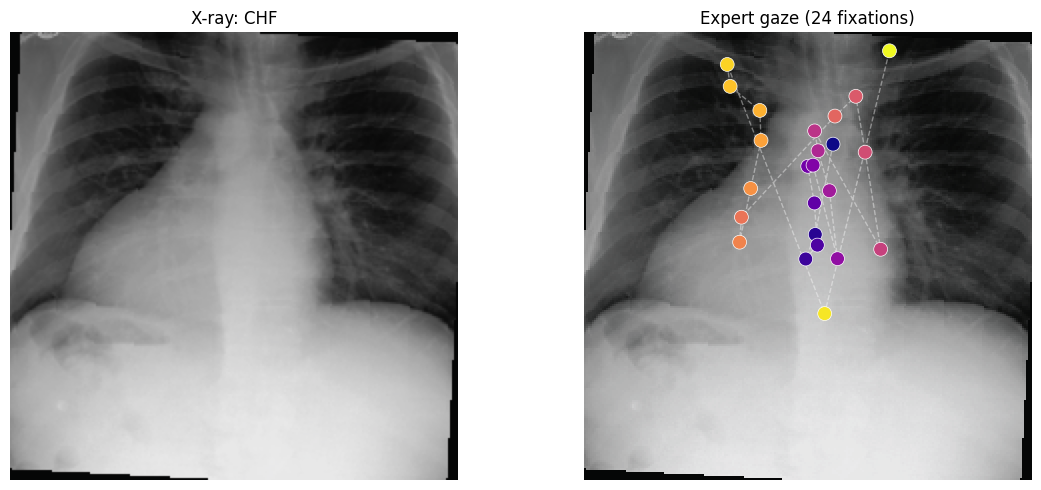

Fixation value range: 0.0 → 1.0


In [11]:
import matplotlib.pyplot as plt, numpy as np

sample = train_ds[0]
img  = sample["image"].permute(1,2,0).numpy()
img  = img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
img  = np.clip(img, 0, 1)
gaze = sample["gaze"].numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img); axes[0].set_title(f"X-ray: {LABEL_NAMES[sample['label'].item()]}"); axes[0].axis("off")
sc = axes[1].imshow(img)
axes[1].scatter(gaze[:,0]*224, gaze[:,1]*224, c=range(len(gaze)),
                cmap="plasma", s=100, zorder=5, edgecolors="white", linewidths=0.5)
axes[1].plot(gaze[:,0]*224, gaze[:,1]*224, "w--", alpha=0.4, linewidth=1)
axes[1].set_title(f"Expert gaze ({len(gaze)} fixations)"); axes[1].axis("off")
plt.tight_layout(); plt.show()
print("Fixation value range:", gaze.min().round(3), "→", gaze.max().round(3))


In [12]:
import os
import torch

class ModelSaver:
    def __init__(self, model: torch.nn.Module, optimizer: torch.optim.Optimizer, cfg: dict):
        """
        Optimized Model Saver tailored for Kaggle Notebook environments.
        Uses the global configuration dictionary (CFG) for parameters.
        """
        # Handle DataParallel/DDP vs Single GPU safely
        if hasattr(model, "module"):
            self.model = model.module
        else:
            self.model = model

        self.optimizer = optimizer
        self.cfg = cfg
        
        # Output directory setup
        self.dir = cfg.get("output_dir", "/kaggle/working/checkpoints")
        os.makedirs(self.dir, exist_ok=True)
        
        # Track the best metric (using a lower bound)
        self.best_metric = -float('inf')

    def __call__(self, epoch, metric=None, is_last_epoch=False):
        """
        Call this at the end of every epoch.
        """
        # Create the comprehensive state dictionary
        state = {
            'epoch': epoch,
            'modelState': self.model.state_dict(),
            'optimizerState': self.optimizer.state_dict(),
            'metric': metric if metric is not None else self.best_metric
        }

        # 1. Save specific checkpoints list
        checkpoints_list = self.cfg.get("checkpointsList", [])
        if epoch in checkpoints_list:
            torch.save(state, os.path.join(self.dir, f"epoch_{epoch}.model"))

        # 2. Save at regular intervals
        interval = self.cfg.get("saveCheckpointInterval", 0)
        if interval > 0 and epoch % interval == 0:
            torch.save(state, os.path.join(self.dir, f"epoch_{epoch}.model"))

        # 3. Save standard rolling checkpoint
        if self.cfg.get("saveCheckpoint", True):
            checkpoint_path = os.path.join(self.dir, "checkpoint.model")
            
            # Handle tearing down the rolling checkpoint on final step if requested
            if is_last_epoch and not self.cfg.get("keepLastCheckpoint", True):
                if os.path.exists(checkpoint_path):
                    os.remove(checkpoint_path)
            else:
                torch.save(state, checkpoint_path)

        # 4. Save best checkpoint based on performance validation metric (e.g., F1 Score)
        if self.cfg.get("keepBestCheckpoint", True) and metric is not None:
            if metric > self.best_metric:
                self.best_metric = metric
                torch.save(state, os.path.join(self.dir, "best_model.pth")) # Kept name matching your inference blocks
                print(f"  ✔ Best model saved successfully (Metric={metric:.4f})")

    def loadLast(self):
        """Finds and loads the highest epoch file explicitly matched."""
        lastEpoch = -1
        if not os.path.exists(self.dir):
            raise RuntimeError(f"Directory not found: {self.dir}")
            
        for file in os.listdir(self.dir):
            if file.startswith("epoch_") and file.endswith(".model"):
                try:
                    epoch = int(file[6:-6])
                    if epoch > lastEpoch:
                        lastEpoch = epoch
                except ValueError:
                    continue
                    
        if lastEpoch == -1:
            # Fallback check for rolling default checkpoint
            if os.path.exists(os.path.join(self.dir, "checkpoint.model")):
                return self.loadModel("checkpoint.model")
            raise RuntimeError(f"No valid checkpoints found in dir: {self.dir}")

        return self.loadModel(f"epoch_{lastEpoch}.model")

    def loadModel(self, filename):
        """Loads weights safely considering potential LoRA or non-strict architectures."""
        path = os.path.join(self.dir, filename)
        state = torch.load(path, map_location='cpu')

        print(f"Loading from epoch {state['epoch']} (File: {filename}).")

        # Dynamically determine strict matching based on whether LoRA is applied in CFG
        use_strict = not (self.cfg.get("lora_rank", 0) > 0)
        
        self.model.load_state_dict(state['modelState'], strict=use_strict)
        self.optimizer.load_state_dict(state['optimizerState'])
        
        # Safely align matching saved keys
        self.best_metric = state.get('metric', -float('inf'))

        return state['epoch']

**| 11 | **TRAIN** |**

In [13]:
import torch.nn.functional as F

# ── compute class weights from ACTUAL train distribution (not guessed) ───────
class_counts = torch.tensor([
    sum(1 for _, lbl in train_ds.samples if lbl == 0),  # CHF
    sum(1 for _, lbl in train_ds.samples if lbl == 1),  # Normal
    sum(1 for _, lbl in train_ds.samples if lbl == 2),  # pneumonia
], dtype=torch.float)

class_weights = (class_counts.sum() / (3.0 * class_counts)).to(DEVICE)
print(f"Train class counts : CHF={int(class_counts[0])} Normal={int(class_counts[1])} pneumonia={int(class_counts[2])}")
print(f"Computed class weights (inverse frequency): {class_weights.cpu().numpy().round(3)}")


def train_one_epoch(model, loader):
    model.train()
    loss_m = AverageMeter()
    all_l, all_p, all_pr = [], [], []

    for batch in loader:
        img   = batch["image"].to(DEVICE)
        gaze  = batch["gaze"].to(DEVICE)
        mask  = batch["gaze_mask"].to(DEVICE)
        lbl   = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        with autocast("cuda", enabled=CFG["amp"]):
            logits = model(img, gaze, mask)
            loss   = F.cross_entropy(logits, lbl, weight=class_weights)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
        scaler.step(optimizer); scaler.update()

        loss_m.update(loss.item(), img.size(0))
        probs = F.softmax(logits.detach(), -1).cpu().numpy()
        all_l.extend(lbl.cpu().tolist()); all_p.extend(probs.argmax(1).tolist()); all_pr.extend(probs.tolist())

    m = compute_metrics(all_l, all_p, all_pr); m["loss"] = loss_m.avg
    return m


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    loss_m = AverageMeter()
    all_l, all_p, all_pr = [], [], []

    for batch in loader:
        img   = batch["image"].to(DEVICE)
        gaze  = batch["gaze"].to(DEVICE)
        mask  = batch["gaze_mask"].to(DEVICE)
        lbl   = batch["label"].to(DEVICE)
        with autocast("cuda", enabled=CFG["amp"]):
            logits = model(img, gaze, mask)
            loss   = F.cross_entropy(logits, lbl)   # no weighting on eval — correct as-is
        loss_m.update(loss.item(), img.size(0))
        probs = F.softmax(logits, -1).cpu().numpy()
        all_l.extend(lbl.cpu().tolist()); all_p.extend(probs.argmax(1).tolist()); all_pr.extend(probs.tolist())

    m = compute_metrics(all_l, all_p, all_pr); m["loss"] = loss_m.avg
    m["_l"] = all_l; m["_p"] = all_p
    return m


# ── Training loop ─────────────────────────────────────────────────────────────
best_f1   = 0.0
history   = {"train_loss":[], "val_loss":[], "train_f1":[], "val_f1":[], "val_auc":[]}

saver = ModelSaver(model, optimizer, CFG)

print(f"Training for {CFG['epochs']} epochs...\n" + "="*70)

for epoch in range(1, CFG["epochs"]+1):
    train_m = train_one_epoch(model, train_loader)
    val_m   = evaluate(model, test_loader)
    scheduler.step()

    history["train_loss"].append(train_m["loss"])
    history["val_loss"].append(val_m["loss"])
    history["train_f1"].append(train_m["f1"])
    history["val_f1"].append(val_m["f1"])
    history["val_auc"].append(val_m["auc"])

    print(f"Ep {epoch:03d}  train_loss={train_m['loss']:.4f} f1={train_m['f1']:.4f}"
          f"  |  val_loss={val_m['loss']:.4f} f1={val_m['f1']:.4f} auc={val_m['auc']:.4f}")

    is_last_epoch = (epoch == CFG["epochs"]) or stopper.counter + 1 >= CFG["patience"]

    saver(epoch=epoch, metric=val_m["f1"], is_last_epoch=is_last_epoch)

    if val_m["f1"] > best_f1:
        best_f1 = val_m["f1"]

    if stopper.step(val_m["f1"]):
        print(f"Early stopping at epoch {epoch}"); break

print("\n" + "="*70)
print(f"Training done. Best Val F1 = {best_f1:.4f}")

Train class counts : CHF=331 Normal=316 pneumonia=329
Computed class weights (inverse frequency): [0.983 1.03  0.989]
Training for 50 epochs...
Ep 001  train_loss=1.7694 f1=0.3624  |  val_loss=0.7954 f1=0.7027 auc=0.8935
  ✔ Best model saved successfully (Metric=0.7027)
Ep 002  train_loss=0.9979 f1=0.5613  |  val_loss=1.0849 f1=0.4491 auc=0.8903
Ep 003  train_loss=0.7982 f1=0.6441  |  val_loss=0.5802 f1=0.7578 auc=0.9300
  ✔ Best model saved successfully (Metric=0.7578)
Ep 004  train_loss=0.7493 f1=0.6871  |  val_loss=0.5908 f1=0.7249 auc=0.9264
Ep 005  train_loss=0.6518 f1=0.7398  |  val_loss=0.5198 f1=0.8008 auc=0.9358
  ✔ Best model saved successfully (Metric=0.8008)
Ep 006  train_loss=0.5815 f1=0.7584  |  val_loss=0.4844 f1=0.8439 auc=0.9326
  ✔ Best model saved successfully (Metric=0.8439)
Ep 007  train_loss=0.5407 f1=0.7827  |  val_loss=0.6010 f1=0.7715 auc=0.9325
Ep 008  train_loss=0.5198 f1=0.7730  |  val_loss=0.6077 f1=0.7792 auc=0.9374
Ep 009  train_loss=0.4937 f1=0.7996  |  

In [14]:
# ── DIAGNOSTIC: inspect what's actually inside the checkpoint file ──────────
best_path = os.path.join(CFG["output_dir"], "best_model.pth")
ckpt = torch.load(best_path, map_location=DEVICE)

print("Type of ckpt:", type(ckpt))
if isinstance(ckpt, dict):
    print("Keys in ckpt:", list(ckpt.keys()))
else:
    print("ckpt is not a dict — it's likely the raw state_dict itself")

Type of ckpt: <class 'dict'>
Keys in ckpt: ['epoch', 'modelState', 'optimizerState', 'metric']


In [15]:
# ── RESET: rebuild a clean model instance and reload trained weights ────────
print("Rebuilding model from scratch to clear any corrupted hooks...")

model = FixationFormer(CFG).to(DEVICE)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

best_path = os.path.join(CFG["output_dir"], "best_model.pth")
ckpt = torch.load(best_path, map_location=DEVICE)
base = model.module if hasattr(model, "module") else model
base.load_state_dict(ckpt["modelState"])
model.eval()

print(f"Model reloaded cleanly from epoch {ckpt['epoch']} (F1={ckpt['metric']:.4f})")
print("layer.img2gaze.forward is now the original, unwrapped method.")

Rebuilding model from scratch to clear any corrupted hooks...
Loading MGCA Medical Pre-trained Weights from /kaggle/input/datasets/vijayadurgaadithya/mgca-weights/vit_base.ckpt....
Loaded 150/150 weights from MGCA. Missing keys: 0, Unexpected keys: 0
LoRA applied (rank=8)
FixationFormer | Total: 109.9M | Trainable: 24.1M
Model reloaded cleanly from epoch 13 (F1=0.8637)
layer.img2gaze.forward is now the original, unwrapped method.


In [16]:
# ── Compute Training Accuracy ───────────────────────────────────────────────
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# 1. Ensure the best model weights are loaded and in eval mode
best_path = "/kaggle/working/checkpoints/best_model.pth"
ckpt = torch.load(best_path, map_location=DEVICE)
base = model.module if hasattr(model, "module") else model
base.load_state_dict(ckpt["modelState"])
model.eval()

train_labels, train_preds = [], []

# 2. Extract predictions across the entire training set
print("Evaluating best model on the training dataset...")
with torch.no_grad():
    for batch in train_loader:
        img = batch["image"].to(DEVICE)
        gaze = batch["gaze"].to(DEVICE)
        mask = batch["gaze_mask"].to(DEVICE)
        lbl = batch["label"]
        
        logits = model(img, gaze, mask)
        probs = F.softmax(logits, dim=-1).cpu().numpy()
        preds = probs.argmax(axis=1)
        
        train_labels.extend(lbl.tolist())
        train_preds.extend(preds.tolist())

# 3. Calculate and display metrics
train_labels = np.array(train_labels)
train_preds = np.array(train_preds)
train_accuracy = accuracy_score(train_labels, train_preds)

print(f"\n=========================================")
print(f" Final Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"=========================================\n")

print("Detailed Training Classification Report:")
print(classification_report(train_labels, train_preds, target_names=LABEL_NAMES, zero_division=0))

Evaluating best model on the training dataset...

 Final Training Accuracy: 82.89%

Detailed Training Classification Report:
              precision    recall  f1-score   support

         CHF       0.81      0.95      0.88       331
      Normal       0.77      0.97      0.86       316
   pneumonia       0.97      0.57      0.72       329

    accuracy                           0.83       976
   macro avg       0.85      0.83      0.82       976
weighted avg       0.85      0.83      0.82       976



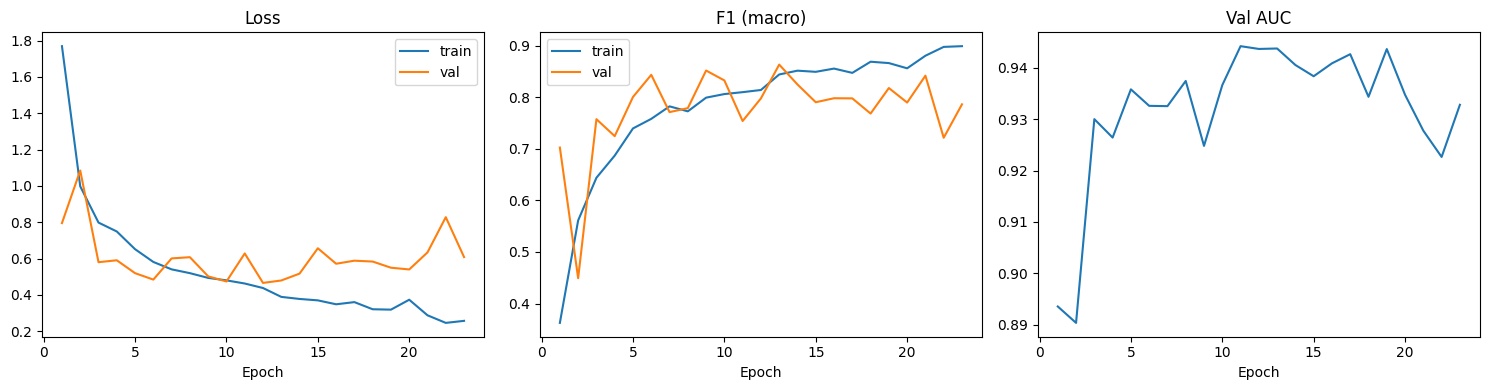


Loading best model...

── Final Test Results ──
[test] Acc=0.8692  AUC=0.9438  P=0.8784  R=0.8575  F1=0.8637

              precision    recall  f1-score   support

         CHF       0.82      0.84      0.83        32
      Normal       0.86      0.95      0.90        44
   pneumonia       0.96      0.77      0.86        31

    accuracy                           0.87       107
   macro avg       0.88      0.86      0.86       107
weighted avg       0.88      0.87      0.87       107



In [17]:
# ── Plot training curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_x = range(1, len(history["train_loss"])+1)

axes[0].plot(epochs_x, history["train_loss"], label="train"); axes[0].plot(epochs_x, history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(epochs_x, history["train_f1"], label="train"); axes[1].plot(epochs_x, history["val_f1"], label="val")
axes[1].set_title("F1 (macro)"); axes[1].legend(); axes[1].set_xlabel("Epoch")

axes[2].plot(epochs_x, history["val_auc"])
axes[2].set_title("Val AUC"); axes[2].set_xlabel("Epoch")

plt.tight_layout(); plt.savefig("/kaggle/working/training_curves.png", dpi=150); plt.show()

# ── Final report from best model ──────────────────────────────────────────────
print("\nLoading best model...")

best_path = "/kaggle/working/checkpoints/best_model.pth"


ckpt  = torch.load(best_path, map_location=DEVICE)
base  = model.module if hasattr(model,"module") else model
base.load_state_dict(ckpt["modelState"])

final = evaluate(model, test_loader)
print("\n── Final Test Results ──")
print_metrics(final, prefix="test")
print()
from sklearn.metrics import classification_report
print(classification_report(final["_l"], final["_p"], target_names=LABEL_NAMES, zero_division=0))


Model loaded from epoch 13 (best F1=0.8637)
Real gaze: 49 fixations

Prediction : CHF  (99.0% confidence)
All probs  : CHF=99.0%  Normal=0.4%  Pneumonia=0.6%
True label : CHF  ✅


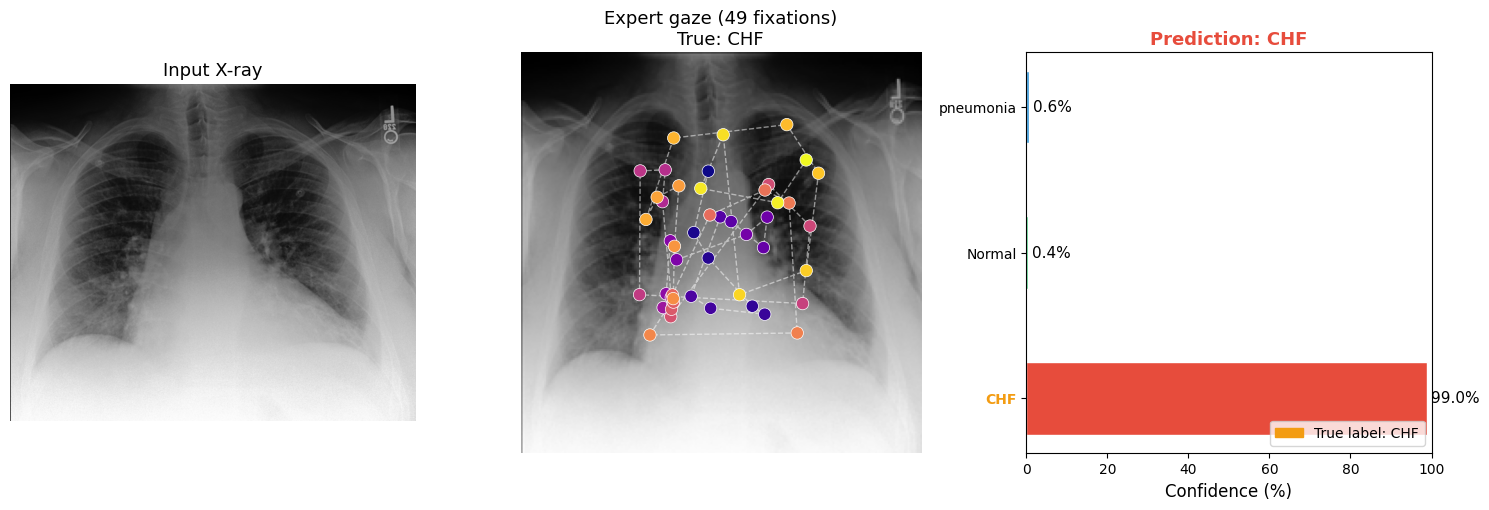

In [18]:
# ── Test with a single image ──────────────────────────────────────────────────
import torch, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from torchvision import transforms

IMAGE_PATH = "/kaggle/input/datasets/vijayadurgaadithya/mimic-part/mimic_part_jpg/test/CHF/05af2f67-a2b15808-de7dbcbb-2f89d568-7625fb4c.jpg"

LABEL_NAMES = ["CHF", "Normal", "pneumonia"]
COLORS      = ["#e74c3c", "#2ecc71", "#3498db"]

# ── Load model from checkpoint ────────────────────────────────────────────────
best_path = "/kaggle/working/checkpoints/best_model.pth"
ckpt = torch.load(best_path, map_location=DEVICE)

# rebuild model if needed (skip if already in memory)
if "model" not in dir() or model is None:
    model = FixationFormer(CFG).to(DEVICE)
base = model.module if hasattr(model, "module") else model
base.load_state_dict(ckpt["modelState"])
model.eval()
print(f"Model loaded from epoch {ckpt['epoch']} (best F1={ckpt['metric']:.4f})")

# ── Image transform (no augmentation — test mode) ─────────────────────────────
infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# ── Load image ────────────────────────────────────────────────────────────────
pil_img = Image.open(IMAGE_PATH).convert("RGB")
img_tensor = infer_transform(pil_img).unsqueeze(0).to(DEVICE)   # (1,3,224,224)

# ── Load gaze for this image (if available) ───────────────────────────────────
dicom_id = os.path.splitext(os.path.basename(IMAGE_PATH))[0]
if dicom_id in csv_index:
    fix = csv_index[dicom_id][:CFG["max_fixations"]]
    print(f"Real gaze: {len(fix)} fixations")
else:
    fix = np.array([[0.5, 0.5, 0.0, 0.2]], dtype=np.float32)
    print("No gaze found — using synthetic centre fixation")

gaze_tensor = torch.from_numpy(fix).unsqueeze(0).to(DEVICE)        # (1,N,4)
gaze_mask   = torch.zeros(1, len(fix), dtype=torch.bool).to(DEVICE) # no padding

# ── Inference ─────────────────────────────────────────────────────────────────
with torch.no_grad():
    logits = model(img_tensor, gaze_tensor, gaze_mask)
    probs  = F.softmax(logits, dim=-1).squeeze().cpu().numpy()
    pred   = probs.argmax()

print(f"\nPrediction : {LABEL_NAMES[pred]}  ({probs[pred]*100:.1f}% confidence)")
print(f"All probs  : CHF={probs[0]*100:.1f}%  Normal={probs[1]*100:.1f}%  Pneumonia={probs[2]*100:.1f}%")

# ── Get true label from folder name ──────────────────────────────────────────
true_label = None
for name, idx in {"CHF":0, "Normal":1, "pneumonia":2}.items():
    if f"/{name}/" in IMAGE_PATH:
        true_label = idx
if true_label is not None:
    match = "✅" if pred == true_label else "❌"
    print(f"True label : {LABEL_NAMES[true_label]}  {match}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Original X-ray
axes[0].imshow(pil_img, cmap="gray")
axes[0].set_title("Input X-ray", fontsize=13)
axes[0].axis("off")

# 2. X-ray + fixation trajectory
img_np = np.array(pil_img.resize((224,224)))
axes[1].imshow(img_np, cmap="gray")
if len(fix) > 1:
    axes[1].scatter(fix[:,0]*224, fix[:,1]*224,
                    c=range(len(fix)), cmap="plasma", s=80, zorder=5,
                    edgecolors="white", linewidths=0.5)
    axes[1].plot(fix[:,0]*224, fix[:,1]*224, "w--", alpha=0.5, linewidth=1)
title = f"Expert gaze ({len(fix)} fixations)"
if true_label is not None:
    title += f"\nTrue: {LABEL_NAMES[true_label]}"
axes[1].set_title(title, fontsize=13)
axes[1].axis("off")

# 3. Prediction bar chart
bars = axes[2].barh(LABEL_NAMES, probs * 100, color=COLORS, edgecolor="white", height=0.5)
axes[2].set_xlim(0, 100)
axes[2].set_xlabel("Confidence (%)", fontsize=12)
axes[2].set_title(f"Prediction: {LABEL_NAMES[pred]}", fontsize=13,
                  color=COLORS[pred], fontweight="bold")
for bar, p in zip(bars, probs):
    axes[2].text(p*100 + 1, bar.get_y() + bar.get_height()/2,
                 f"{p*100:.1f}%", va="center", fontsize=11)
if true_label is not None:
    axes[2].get_yticklabels()[true_label].set_fontweight("bold")
    axes[2].get_yticklabels()[true_label].set_color("#f39c12")
    patch = mpatches.Patch(color="#f39c12", label=f"True label: {LABEL_NAMES[true_label]}")
    axes[2].legend(handles=[patch], loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("/kaggle/working/single_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

Model loaded from epoch 13 (best F1=0.8637)
Real gaze: 35 fixations

Prediction : pneumonia  (99.3% confidence)
All probs  : CHF=0.2%  Normal=0.6%  Pneumonia=99.3%
True label : pneumonia  ✅


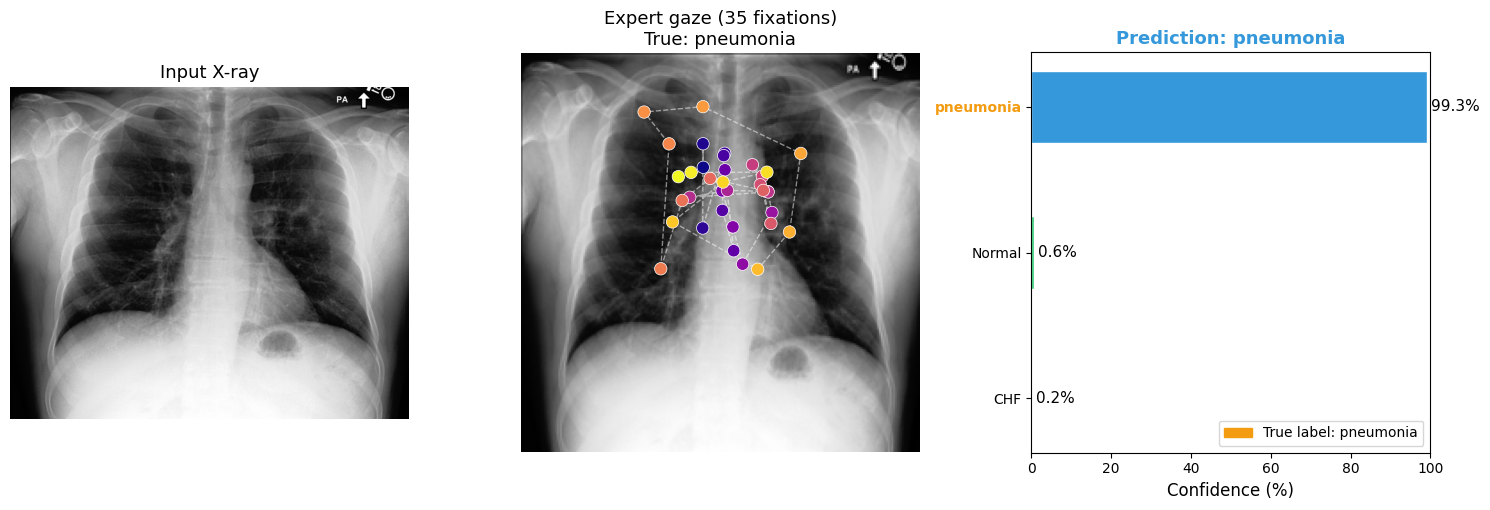

In [19]:
# ── Test with a single image ──────────────────────────────────────────────────
import torch, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from torchvision import transforms

# ╔══════════════════════════════════════════════════════════════╗
# ║  SET YOUR IMAGE PATH HERE                                    ║
# ╚══════════════════════════════════════════════════════════════╝
IMAGE_PATH = "/kaggle/input/datasets/vijayadurgaadithya/mimic-part/mimic_part_jpg/test/pneumonia/fab8837f-b4464796-00f5e343-4ba4077c-333b5ba9.jpg"
# You can also use any image from train/test folders:
# IMAGE_PATH = train_ds.samples[0][0]   ← first training image
# IMAGE_PATH = test_ds.samples[5][0]    ← 6th test image

LABEL_NAMES = ["CHF", "Normal", "pneumonia"]
COLORS      = ["#e74c3c", "#2ecc71", "#3498db"]

# ── Load model from checkpoint ────────────────────────────────────────────────
best_path = "/kaggle/working/checkpoints/best_model.pth"
ckpt = torch.load(best_path, map_location=DEVICE)

# rebuild model if needed (skip if already in memory)
if "model" not in dir() or model is None:
    model = FixationFormer(CFG).to(DEVICE)
base = model.module if hasattr(model, "module") else model
base.load_state_dict(ckpt["modelState"])
model.eval()
print(f"Model loaded from epoch {ckpt['epoch']} (best F1={ckpt['metric']:.4f})")

# ── Image transform (no augmentation — test mode) ─────────────────────────────
infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# ── Load image ────────────────────────────────────────────────────────────────
pil_img = Image.open(IMAGE_PATH).convert("RGB")
img_tensor = infer_transform(pil_img).unsqueeze(0).to(DEVICE)   # (1,3,224,224)

# ── Load gaze for this image (if available) ───────────────────────────────────
dicom_id = os.path.splitext(os.path.basename(IMAGE_PATH))[0]
if dicom_id in csv_index:
    fix = csv_index[dicom_id][:CFG["max_fixations"]]
    print(f"Real gaze: {len(fix)} fixations")
else:
    fix = np.array([[0.5, 0.5, 0.0, 0.2]], dtype=np.float32)
    print("No gaze found — using synthetic centre fixation")

gaze_tensor = torch.from_numpy(fix).unsqueeze(0).to(DEVICE)        # (1,N,4)
gaze_mask   = torch.zeros(1, len(fix), dtype=torch.bool).to(DEVICE) # no padding

# ── Inference ─────────────────────────────────────────────────────────────────
with torch.no_grad():
    logits = model(img_tensor, gaze_tensor, gaze_mask)
    probs  = F.softmax(logits, dim=-1).squeeze().cpu().numpy()
    pred   = probs.argmax()

print(f"\nPrediction : {LABEL_NAMES[pred]}  ({probs[pred]*100:.1f}% confidence)")
print(f"All probs  : CHF={probs[0]*100:.1f}%  Normal={probs[1]*100:.1f}%  Pneumonia={probs[2]*100:.1f}%")

# ── Get true label from folder name ──────────────────────────────────────────
true_label = None
for name, idx in {"CHF":0, "Normal":1, "pneumonia":2}.items():
    if f"/{name}/" in IMAGE_PATH:
        true_label = idx
if true_label is not None:
    match = "✅" if pred == true_label else "❌"
    print(f"True label : {LABEL_NAMES[true_label]}  {match}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Original X-ray
axes[0].imshow(pil_img, cmap="gray")
axes[0].set_title("Input X-ray", fontsize=13)
axes[0].axis("off")

# 2. X-ray + fixation trajectory
img_np = np.array(pil_img.resize((224,224)))
axes[1].imshow(img_np, cmap="gray")
if len(fix) > 1:
    axes[1].scatter(fix[:,0]*224, fix[:,1]*224,
                    c=range(len(fix)), cmap="plasma", s=80, zorder=5,
                    edgecolors="white", linewidths=0.5)
    axes[1].plot(fix[:,0]*224, fix[:,1]*224, "w--", alpha=0.5, linewidth=1)
title = f"Expert gaze ({len(fix)} fixations)"
if true_label is not None:
    title += f"\nTrue: {LABEL_NAMES[true_label]}"
axes[1].set_title(title, fontsize=13)
axes[1].axis("off")

# 3. Prediction bar chart
bars = axes[2].barh(LABEL_NAMES, probs * 100, color=COLORS, edgecolor="white", height=0.5)
axes[2].set_xlim(0, 100)
axes[2].set_xlabel("Confidence (%)", fontsize=12)
axes[2].set_title(f"Prediction: {LABEL_NAMES[pred]}", fontsize=13,
                  color=COLORS[pred], fontweight="bold")
for bar, p in zip(bars, probs):
    axes[2].text(p*100 + 1, bar.get_y() + bar.get_height()/2,
                 f"{p*100:.1f}%", va="center", fontsize=11)
if true_label is not None:
    axes[2].get_yticklabels()[true_label].set_fontweight("bold")
    axes[2].get_yticklabels()[true_label].set_color("#f39c12")
    patch = mpatches.Patch(color="#f39c12", label=f"True label: {LABEL_NAMES[true_label]}")
    axes[2].legend(handles=[patch], loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("/kaggle/working/single_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# ── DIAGNOSTIC: check what's being passed to roc_auc_score ───────────────────
import torch, torch.nn.functional as F
import numpy as np

model.eval()
all_labels, all_probs, all_preds = [], [], []

with torch.no_grad():
    for batch in test_loader:
        img  = batch["image"].to(DEVICE)
        gaze = batch["gaze"].to(DEVICE)
        mask = batch["gaze_mask"].to(DEVICE)
        lbl  = batch["label"]

        logits = model(img, gaze, mask)
        probs  = F.softmax(logits, dim=-1).cpu().numpy()   # (B, 3)
        preds  = probs.argmax(axis=1)                       # (B,)

        all_labels.extend(lbl.tolist())
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())

all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print("all_labels shape :", all_labels.shape)
print("all_probs  shape :", all_probs.shape)
print("unique labels    :", np.unique(all_labels))
print("prob row sum     :", all_probs.sum(axis=1)[:5].round(4))  # should all be ~1.0
print("prob sample      :", all_probs[:3].round(4))
print("prob min/max     :", all_probs.min().round(4), all_probs.max().round(4))

all_labels shape : (107,)
all_probs  shape : (107, 3)
unique labels    : [0 1 2]
prob row sum     : [1. 1. 1. 1. 1.]
prob sample      : [[0.9896 0.0044 0.006 ]
 [0.101  0.5097 0.3893]
 [0.9546 0.0427 0.0027]]
prob min/max     : 0.0 0.9997


In [21]:
# ── FIXED AUC computation ─────────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import label_binarize

# all_labels and all_probs already collected above

# Method 1: standard ovr
try:
    auc_ovr = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
    print(f"AUC (OvR macro) : {auc_ovr:.4f}")
except Exception as e:
    print(f"OvR failed: {e}")

# Method 2: ovo (more robust with class imbalance)
try:
    auc_ovo = roc_auc_score(all_labels, all_probs, multi_class="ovo", average="macro")
    print(f"AUC (OvO macro) : {auc_ovo:.4f}")
except Exception as e:
    print(f"OvO failed: {e}")

# Method 3: per-class AUC manually (most robust, shows which class causes the issue)
labels_bin = label_binarize(all_labels, classes=[0, 1, 2])  # (N, 3)
print(f"\nPer-class AUC:")
for i, name in enumerate(["CHF", "Normal", "Pneumonia"]):
    try:
        auc_i = roc_auc_score(labels_bin[:, i], all_probs[:, i])
        print(f"  {name:12s}: {auc_i:.4f}  (n={labels_bin[:,i].sum()})")
    except Exception as e:
        print(f"  {name:12s}: FAILED — {e}")

# Final report
print(f"\nAccuracy : {(np.array(all_preds) == all_labels).mean():.4f}")
print(classification_report(all_labels, all_preds,
                             target_names=["CHF","Normal","Pneumonia"], zero_division=0))

AUC (OvR macro) : 0.9438
AUC (OvO macro) : 0.9407

Per-class AUC:
  CHF         : 0.9221  (n=32)
  Normal      : 0.9639  (n=44)
  Pneumonia   : 0.9452  (n=31)

Accuracy : 0.8692
              precision    recall  f1-score   support

         CHF       0.82      0.84      0.83        32
      Normal       0.86      0.95      0.90        44
   Pneumonia       0.96      0.77      0.86        31

    accuracy                           0.87       107
   macro avg       0.88      0.86      0.86       107
weighted avg       0.88      0.87      0.87       107



In [22]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Convert collected lists from your test loop to numpy arrays
y_true = np.array(all_labels)
y_pred = np.array(all_preds)

# 1. Calculate overall test accuracy
test_accuracy = accuracy_score(y_true, y_pred)
print(f"=========================================")
print(f" Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"=========================================\n")

# 2. Print a detailed per-class breakdown (Precision, Recall, F1)
print("Detailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, zero_division=0))

 Final Test Accuracy: 86.92%

Detailed Classification Report:
              precision    recall  f1-score   support

         CHF       0.82      0.84      0.83        32
      Normal       0.86      0.95      0.90        44
   pneumonia       0.96      0.77      0.86        31

    accuracy                           0.87       107
   macro avg       0.88      0.86      0.86       107
weighted avg       0.88      0.87      0.87       107



In [23]:
# Cell [51] — run this first, then run New Cell A
eval_model = model.module if hasattr(model, "module") else model
eval_model = eval_model.to(DEVICE)
eval_model.eval()
print(f"eval_model ready on: {next(eval_model.parameters()).device}")

eval_model ready on: cuda:0


Confusion Matrix (rows=true, cols=predicted):
                 CHF  Normal    Pneu
CHF               27       4       1
Normal             2      42       0
pneumonia          4       3      24

True pneumonia → predicted CHF: 4/31 (12.9% of all pneumonia cases)

Misclassified pneumonia→CHF cases (with confidence):
  1f8e2b6b-5fad5e90-0734669e-e4f53b50-77bb2539.jpg  →  predicted CHF at 71.6% confidence (true pneumonia prob was only 28.3%)
  299e7754-5dead048-0a423962-464ffb32-a71e98b1.jpg  →  predicted CHF at 96.9% confidence (true pneumonia prob was only 3.0%)
  ab2e5ae7-0c8d8980-ddbe5385-6330431b-3981574d.jpg  →  predicted CHF at 95.3% confidence (true pneumonia prob was only 4.6%)
  d646869c-07a54ebb-590c4a37-78ac0242-c3e2985d.jpg  →  predicted CHF at 87.6% confidence (true pneumonia prob was only 12.1%)


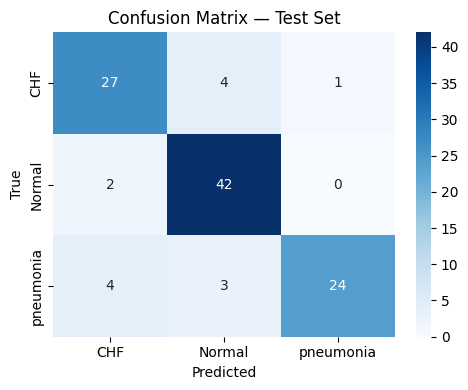

In [24]:
# ── DIAGNOSTIC: where exactly is the classifier confusing CHF and pneumonia? ─
from sklearn.metrics import confusion_matrix
import seaborn as sns


@torch.no_grad()
def run_full_test_eval(eval_model, test_loader):
    eval_model.eval()
    all_labels, all_preds, all_probs, all_paths = [], [], [], []
    for batch in test_loader:
        img = batch["image"].to(DEVICE)
        gaze = batch["gaze"].to(DEVICE)
        mask = batch["gaze_mask"].to(DEVICE)
        logits = eval_model(img, gaze, mask)    # ← single-GPU model, no DataParallel
        probs = F.softmax(logits, -1).cpu().numpy()
        all_labels.extend(batch["label"].tolist())
        all_preds.extend(probs.argmax(1).tolist())
        all_probs.extend(probs.tolist())
        all_paths.extend(batch["path"])
    return np.array(all_labels), np.array(all_preds), np.array(all_probs), all_paths


labels, preds, probs, paths = run_full_test_eval(eval_model, test_loader)

cm = confusion_matrix(labels, preds)
print("Confusion Matrix (rows=true, cols=predicted):")
print(f"{'':12s}{'CHF':>8s}{'Normal':>8s}{'Pneu':>8s}")
for i, name in enumerate(LABEL_NAMES):
    print(f"{name:12s}{cm[i,0]:>8d}{cm[i,1]:>8d}{cm[i,2]:>8d}")

pneu_idx = LABEL_NAMES.index("pneumonia")
chf_idx  = LABEL_NAMES.index("CHF")
pneu_as_chf = cm[pneu_idx, chf_idx]
total_pneu  = cm[pneu_idx].sum()
print(f"\nTrue pneumonia → predicted CHF: {pneu_as_chf}/{total_pneu} "
      f"({pneu_as_chf/total_pneu*100:.1f}% of all pneumonia cases)")

print(f"\nMisclassified pneumonia→CHF cases (with confidence):")
mask_wrong = (labels == pneu_idx) & (preds == chf_idx)
wrong_indices = np.where(mask_wrong)[0]
for i in wrong_indices:
    print(f"  {os.path.basename(paths[i])}  →  predicted CHF at {probs[i][chf_idx]*100:.1f}% confidence "
         f"(true pneumonia prob was only {probs[i][pneu_idx]*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
           xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
plt.show()

In [25]:
# ── DIAGNOSTIC: check for invalid coordinates in the fixation pipeline ───────
image_path = "/kaggle/input/mimic-gaze-jpg/mimic_part_jpg/test/pneumonia/ab2e5ae7-0c8d8980-ddbe5385-6330431b-3981574d.jpg"
dicom_id = os.path.splitext(os.path.basename(image_path))[0]
fix = csv_index[dicom_id][:50]

print(f"Fixation array shape: {fix.shape}")
print(f"x range: {fix[:,0].min():.4f} to {fix[:,0].max():.4f}")
print(f"y range: {fix[:,1].min():.4f} to {fix[:,1].max():.4f}")
print(f"Any x or y outside [0,1]? {(fix[:,0]<0).any() or (fix[:,0]>1).any() or (fix[:,1]<0).any() or (fix[:,1]>1).any()}")

# print every fixation as pixel coords to find the 9999 value
for i, (x, y, t, d) in enumerate(fix):
    px, py = round(float(x)*224), round(float(y)*224)
    if px > 224 or py > 224 or px < 0 or py < 0:
        print(f"⚠️  INVALID at fixation #{i+1}: pixel({px},{py}) from norm({x:.4f},{y:.4f})")

Fixation array shape: (50, 4)
x range: 0.2315 to 0.7283
y range: 0.2278 to 0.8696
Any x or y outside [0,1]? False


In [26]:
import os
from IPython.display import FileLink

# Use a path relative to /kaggle/working
relative_model_path = "checkpoints/best_model.pth"

if os.path.exists(relative_model_path):
    print("Click the link below to download your model instantly:")
    display(FileLink(relative_model_path))
else:
    print(f"File not found at {relative_model_path}.")
    print("Double check if it's named differently in your output sidebar.")

Click the link below to download your model instantly:


/kaggle/working/checkpoints/best_model.pth

In [27]:
class AttentionCapture:
    """Wraps the model's Two-Way attention to capture weights during forward."""
    def __init__(self, model):
        self.model = model
        self.captured = {}
        self._originals = {}   # store original forward methods so we can restore them
        self._register()

    def _register(self):
        base = self.model.module if hasattr(self.model, "module") else self.model
        integration = base.integration

        for layer_idx, layer in enumerate(integration.layers):
            # ── restore first, in case this layer was already wrapped ────────
            if layer_idx in self._originals:
                continue   # already registered on this instance, skip

            orig_img2gaze = layer.img2gaze.forward
            orig_gaze2img = layer.gaze2img.forward
            self._originals[layer_idx] = (orig_img2gaze, orig_gaze2img)

            def make_img2gaze_hook(idx, orig):
                def hooked_forward(query, key, value, **kwargs):
                    kwargs.pop("need_weights", None)            # avoid duplicate kwarg
                    kwargs.pop("average_attn_weights", None)
                    out, weights = orig(query, key, value,
                                        need_weights=True, average_attn_weights=False, **kwargs)
                    self.captured.setdefault(idx, {})["img2gaze"] = weights.detach().cpu()
                    return out, weights
                return hooked_forward

            def make_gaze2img_hook(idx, orig):
                def hooked_forward(query, key, value, **kwargs):
                    kwargs.pop("need_weights", None)
                    kwargs.pop("average_attn_weights", None)
                    out, weights = orig(query, key, value,
                                        need_weights=True, average_attn_weights=False, **kwargs)
                    self.captured.setdefault(idx, {})["gaze2img"] = weights.detach().cpu()
                    return out, weights
                return hooked_forward

            layer.img2gaze.forward = make_img2gaze_hook(layer_idx, orig_img2gaze)
            layer.gaze2img.forward = make_gaze2img_hook(layer_idx, orig_gaze2img)

    def restore(self):
        """Unwraps the hooks, returning the model's attention layers to their original state."""
        base = self.model.module if hasattr(self.model, "module") else self.model
        integration = base.integration
        for layer_idx, layer in enumerate(integration.layers):
            if layer_idx in self._originals:
                orig_img2gaze, orig_gaze2img = self._originals[layer_idx]
                layer.img2gaze.forward = orig_img2gaze
                layer.gaze2img.forward = orig_gaze2img
        self._originals = {}

    def clear(self):
        self.captured = {}


print("AttentionCapture (fixed, restorable) defined.")

AttentionCapture (fixed, restorable) defined.


In [28]:
# ── NEW CELL A: Save FixationFormer outputs for Notebook 2 ───────────────────
import json, pickle, os
import numpy as np
import torch.nn.functional as F

save_dir = "/kaggle/working/fixationformer_outputs"
os.makedirs(save_dir, exist_ok=True)

eval_model.eval()
test_results = {}
attention_data = {}

for img_path, true_label in test_ds.samples:
    dicom_id = os.path.splitext(os.path.basename(img_path))[0]
    if dicom_id not in csv_index:
        continue

    fix = csv_index[dicom_id][:CFG["max_fixations"]]
    N = len(fix)

    img_t = infer_transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to(DEVICE)
    g_t   = torch.from_numpy(fix).unsqueeze(0).to(DEVICE)
    m_t   = torch.zeros(1, N, dtype=torch.bool).to(DEVICE)

    capturer = AttentionCapture(eval_model)
    capturer.clear()
    with torch.no_grad():
        logits = eval_model(img_t, g_t, m_t)
        probs  = F.softmax(logits, -1).squeeze().cpu().numpy()
    pred = int(probs.argmax())

    lw = capturer.captured
    capturer.restore()

    if lw and "img2gaze" in lw.get(max(lw.keys()), {}):
        last = max(lw.keys())
        weights = lw[last]["img2gaze"][0].mean(0).sum(0).numpy()
    else:
        weights = np.ones(N) / N

    top_k_idx = np.argsort(weights)[::-1][:5].tolist()

    # classification results
    test_results[dicom_id] = {
        "image_path":   img_path,
        "true_label":   int(true_label),
        "prediction":   LABEL_NAMES[pred],
        "confidence":   float(probs[pred]),
        "probs":        probs.tolist(),
        "n_fixations":  N,
    }

    # attention + gaze data
    attention_data[dicom_id] = {
        "fix":          fix.tolist(),
        "weights":      weights.tolist(),
        "top_k_idx":    top_k_idx,
    }

# save
with open(f"{save_dir}/test_results.json", "w") as f:
    json.dump(test_results, f)
with open(f"{save_dir}/attention_weights.json", "w") as f:
    json.dump(attention_data, f)
with open(f"{save_dir}/csv_index.pkl", "wb") as f:
    pickle.dump(csv_index, f)

print(f"Saved {len(test_results)} test results to {save_dir}/")
print("Files:")
for fname in os.listdir(save_dir):
    size = os.path.getsize(f"{save_dir}/{fname}") / 1e6
    print(f"  {fname}: {size:.2f} MB")

Saved 107 test results to /kaggle/working/fixationformer_outputs/
Files:
  test_results.json: 0.04 MB
  attention_weights.json: 0.45 MB
  csv_index.pkl: 0.88 MB


In [29]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import io

def render_gaze_overlay(image_path, fix, top_k_idx=None, save_path=None):
    pil_img = Image.open(image_path).convert("RGB")
    img_np = np.array(pil_img.resize((224, 224)))

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img_np)
    ax.scatter(fix[:,0]*224, fix[:,1]*224, c=range(len(fix)), cmap="plasma",
              s=70, zorder=5, edgecolors="white", linewidths=0.5, alpha=0.85)
    ax.plot(fix[:,0]*224, fix[:,1]*224, "w--", alpha=0.4, linewidth=1)

    if top_k_idx is not None:
        top_x = [fix[i,0]*224 for i in top_k_idx]
        top_y = [fix[i,1]*224 for i in top_k_idx]
        ax.scatter(top_x, top_y, c="red", s=160, zorder=6,
                  edgecolors="yellow", linewidths=1.5, marker="*")

    ax.axis("off")
    plt.tight_layout(pad=0)
    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=100, bbox_inches="tight", pad_inches=0)
    plt.close(fig)
    buf.seek(0)
    overlay_img = Image.open(buf).convert("RGB")
    if save_path:
        overlay_img.save(save_path)
    return overlay_img


def build_structured_description(image_path, model, csv_index, df_full,
                                  max_fixations=50, top_k=5):
    dicom_id = os.path.splitext(os.path.basename(image_path))[0]
    if dicom_id not in csv_index:
        return None, None, None

    fix = csv_index[dicom_id][:max_fixations]
    N = len(fix)
    base_model = model.module if hasattr(model, "module") else model
    base_model.eval()

    img_t = infer_transform(Image.open(image_path).convert("RGB")).unsqueeze(0).to(DEVICE)
    g_t   = torch.from_numpy(fix).unsqueeze(0).to(DEVICE)
    m_t   = torch.zeros(1, N, dtype=torch.bool).to(DEVICE)

    capturer = AttentionCapture(model)
    capturer.clear()
    with torch.no_grad():
        logits = base_model(img_t, g_t, m_t)
        probs = F.softmax(logits, dim=-1).squeeze().cpu().numpy()
    pred = int(probs.argmax())

    lw = capturer.captured
    capturer.restore()

    if lw and "img2gaze" in lw.get(max(lw.keys()), {}):
        last = max(lw.keys())
        fi = lw[last]["img2gaze"][0].mean(0).sum(0).numpy()
        top_k_idx = np.argsort(fi)[::-1][:top_k]
    else:
        top_k_idx = np.arange(min(top_k, N))

    # ── NEW: geometry-based description (primary spatial signal) ──────────────
    geometry = compute_gaze_geometry(fix, top_k_idx, img_width=224, img_height=224)

    # ── existing zone labels, kept as a secondary/coarse hint ──────────────────
    zone_counts = {}
    for idx in top_k_idx:
        zone = get_anatomical_zone(fix[idx, 0], fix[idx, 1])
        zone_counts[zone] = zone_counts.get(zone, 0) + 1
    top_zones = sorted(zone_counts.items(), key=lambda x: -x[1])
    zone_str = ", ".join(f"{z} ({c} fixations)" for z, c in top_zones[:3])

    fix_df_raw = df_full[df_full["DICOM_ID"] == dicom_id].head(max_fixations) if df_full is not None else None
    saccade_pattern = analyse_saccade_pattern(fix_df_raw)

    confidence_note = ""
    if probs[pred] < 0.70:
        confidence_note = " [PROVISIONAL — confidence below 70%]"

    structured_text = (
        f"AI Classification Result: {LABEL_NAMES[pred]} (confidence: {probs[pred]*100:.1f}%){confidence_note}\n"
        f"Class probabilities: CHF={probs[0]*100:.1f}%, Normal={probs[1]*100:.1f}%, Pneumonia={probs[2]*100:.1f}%\n"
        f"Total expert-style fixations analyzed: {N}\n"
        f"\n"
        f"TOP-{top_k} MOST INFLUENTIAL FIXATIONS (pixel coordinates on 224x224 image):\n"
        f"  Individual points: {geometry['pixel_points']}\n"
        f"  Centroid (center of attention): {geometry['pixel_centroid']}\n"
        f"  Bounding area: {geometry['pixel_bbox']} (x_min,y_min,x_max,y_max)\n"
        f"  Spatial description: {geometry['spread_desc']}, located in the "
        f"{geometry['horizontal_desc']}, {geometry['vertical_desc']}\n"
        f"\n"
        f"Coarse anatomical zone hint (may be imprecise near boundaries — verify against image): {zone_str}\n"
        f"Gaze scanning pattern: {saccade_pattern}\n"
    )

    return structured_text, fix, top_k_idx

In [30]:
# ── NEW CELL B: Pre-render gaze overlays — Notebook 2 needs no FixationFormer
import matplotlib.pyplot as plt
import io
from PIL import Image

overlay_dir = f"{save_dir}/gaze_overlays"
os.makedirs(overlay_dir, exist_ok=True)

for dicom_id, att in attention_data.items():
    fix      = np.array(att["fix"])
    top_k    = np.array(att["top_k_idx"])
    img_path = test_results[dicom_id]["image_path"]

    pil_img = Image.open(img_path).convert("RGB")
    img_np  = np.array(pil_img.resize((224, 224)))

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img_np)
    ax.scatter(fix[:,0]*224, fix[:,1]*224, c=range(len(fix)), cmap="plasma",
               s=70, zorder=5, edgecolors="white", linewidths=0.5, alpha=0.85)
    ax.plot(fix[:,0]*224, fix[:,1]*224, "w--", alpha=0.4, linewidth=1)

    for idx in top_k[:3]:
        px, py = fix[idx,0]*224, fix[idx,1]*224
        ax.scatter(px, py, c="red", s=160, zorder=6,
                   edgecolors="yellow", linewidths=1.5, marker="*")

    ax.axis("off")
    plt.tight_layout(pad=0)
    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=100, bbox_inches="tight", pad_inches=0)
    plt.close(fig)
    buf.seek(0)
    Image.open(buf).convert("RGB").save(f"{overlay_dir}/{dicom_id}.png")

print(f"Saved {len(attention_data)} gaze overlay images to {overlay_dir}/")

Saved 107 gaze overlay images to /kaggle/working/fixationformer_outputs/gaze_overlays/


In [31]:
# ── NEW CELL C: Zip all outputs for download + use in Notebook 2 ─────────────
import shutil

zip_path = "/kaggle/working/fixationformer_outputs"
shutil.make_archive(zip_path, "zip", save_dir)
print(f"Created: {zip_path}.zip")
print(f"Size: {os.path.getsize(zip_path+'.zip')/1e6:.1f} MB")
print()
print("Upload this zip + best_model.pth as a Kaggle dataset for Notebook 2.")
print("Notebook 2 will NEVER need to load FixationFormer model weights.")

Created: /kaggle/working/fixationformer_outputs.zip
Size: 15.3 MB

Upload this zip + best_model.pth as a Kaggle dataset for Notebook 2.
Notebook 2 will NEVER need to load FixationFormer model weights.
